## LOAD DATA

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
url = "https://raw.githubusercontent.com/Sidqixx/data_responden/main/Preprocessed%20Responden1.csv"
df = pd.read_csv(url)
df.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63
0,Iya,Jakarta,Rumah,4,Sejuk,> 2200 VA,Tidak,lebih dari 20,Tidak ada,Tidak ada,...,3-8 Jam,9-12 Jam,TIdak,Tidak mempunyai kendaraan listrik,Rp. 1.000.001 - Rp 1.500.000,Naik Turun ( Tiap Bulan Naik 100.000 atau Turu...,"Januari, Juni, Juli, Desember",Malam (19:00 - 04:59),3.0,mengurangi penggunaan alat elektronik untuk me...
1,Iya,Bandung,Rumah,4,Sejuk,> 2200 VA,Ya,lebih dari 20,2,1,...,3-8 Jam,9-12 Jam,Ya,Tidak mempunyai kendaraan listrik,Rp. 1.500.001 - Rp 2.000.000,Stabil ( Tiap Bulan Beda 100.000),Tidak Ada perbedaan signifikan,Sore (16:00 - 18:59),2.0,-
2,Iya,Bandung,Kos,1,Sejuk,900 VA,Ya,1-5,1,Tidak ada,...,<2 Jam,<2 Jam,TIdak,Tidak mempunyai kendaraan listrik,< Rp. 500.000,Stabil ( Tiap Bulan Beda 100.000),"November, Desember",Malam (19:00 - 04:59),4.0,tidak menyalakan alat yg tidak sering dipakai
3,Iya,Jakarta,Rumah,> 5,Panas,> 2200 VA,Ya,lebih dari 20,1,1,...,3-8 Jam,9-12 Jam,Ya,Tidak mempunyai kendaraan listrik,> Rp 2.000.000,Naik Turun ( Tiap Bulan Naik 100.000 atau Turu...,Tidak Ada perbedaan signifikan,Malam (19:00 - 04:59),3.0,pergi
4,Iya,Jakarta,Rumah,5,Panas,900 VA,Ya,lebih dari 20,1,Tidak ada,...,<2 Jam,9-12 Jam,TIdak,Tidak mempunyai kendaraan listrik,Rp. 1.500.001 - Rp 2.000.000,Stabil ( Tiap Bulan Beda 100.000),September,Malam (19:00 - 04:59),3.0,Menghemat pengunaan listrik


In [ ]:
#Jumlah Kolom awal
len(df.columns)

63

In [ ]:
drop_cols = [
    'x2',   # Kota tempat tinggal (terlalu banyak kategori)
    'x25','x26','x27','x28','x29','x30','x31','x32','x33','x34',  # ranking peralatan elektronik
    'x63', 'x59', 'x61', 'x62'   # Bagaimana mengurangi Penggunaan listrik (jawaban teks)
]

df = df.drop(columns=drop_cols, errors='ignore')
df.head()

,x1,x3,x4,x5,x6,x7,x8,x9,x10,x11,...,x50,x51,x52,x53,x54,x55,x56,x57,x58,x60
0,Iya,Rumah,4,Sejuk,> 2200 VA,Tidak,lebih dari 20,Tidak ada,Tidak ada,1,...,9-12 Jam,> 12 Jam,3-8 Jam,3-8 Jam,3-8 Jam,9-12 Jam,TIdak,Tidak mempunyai kendaraan listrik,Rp. 1.000.001 - Rp 1.500.000,"Januari, Juni, Juli, Desember"
1,Iya,Rumah,4,Sejuk,> 2200 VA,Ya,lebih dari 20,2,1,1,...,> 12 Jam,3-8 Jam,9-12 Jam,9-12 Jam,3-8 Jam,9-12 Jam,Ya,Tidak mempunyai kendaraan listrik,Rp. 1.500.001 - Rp 2.000.000,Tidak Ada perbedaan signifikan
2,Iya,Kos,1,Sejuk,900 VA,Ya,1-5,1,Tidak ada,Tidak ada,...,9-12 Jam,<2 Jam,<2 Jam,<2 Jam,<2 Jam,<2 Jam,TIdak,Tidak mempunyai kendaraan listrik,< Rp. 500.000,"November, Desember"
3,Iya,Rumah,> 5,Panas,> 2200 VA,Ya,lebih dari 20,1,1,1,...,9-12 Jam,<2 Jam,<2 Jam,<2 Jam,3-8 Jam,9-12 Jam,Ya,Tidak mempunyai kendaraan listrik,> Rp 2.000.000,Tidak Ada perbedaan signifikan
4,Iya,Rumah,5,Panas,900 VA,Ya,lebih dari 20,1,Tidak ada,1,...,3-8 Jam,<2 Jam,3-8 Jam,3-8 Jam,<2 Jam,9-12 Jam,TIdak,Tidak mempunyai kendaraan listrik,Rp. 1.500.001 - Rp 2.000.000,September


In [ ]:
#Drop Kolom yang susah/ tidak bisa dinterpretasikan
len(df.columns)

48

### Nanti Buang

In [ ]:
cols_before_mapping = df.columns.tolist()

print("=== SEBELUM MAPPING ===")
print(f"Jumlah kolom : {len(cols_before_mapping)}")
for c in cols_before_mapping:
    print(c)


=== SEBELUM MAPPING ===
Jumlah kolom : 48
x1
x3
x4
x5
x6
x7
x8
x9
x10
x11
x12
x13
x14
x15
x16
x17
x18
x19
x20
x21
x22
x23
x24
x35
x36
x37
x38
x39
x40
x41
x42
x43
x44
x45
x46
x47
x48
x49
x50
x51
x52
x53
x54
x55
x56
x57
x58
x60


In [ ]:
df.to_csv("before_cleaning.csv")

## MAPPING QUANTITATIVE TO NUMERIC

In [ ]:
mapping_durasi_jam = {
    'tidak punya tv': 0, 'tidak punya ac/kipas angin': 0, 'tidak punya komputer':0,
    'tidak mempunyai kendaraan listrik':0,
    '1-2 jam': 2,
    '>4 jam': 4,
    '3-4 jam': 3,
    '<2 jam': 2, '< 2 jam': 2,
    '2-4 jam': 4, '2 - 4 jam': 4,
    '4-8 jam': 8, '4 - 8 jam': 8,
    '3-8 jam': 8, '3 - 8 jam': 8,
    '8-12 jam': 12, '8 - 12 jam': 12,
    '>8 jam': 12, '> 8 jam': 12,
    '>12 jam': 14, '> 12 jam': 14,
    '9-12 jam': 12
}

mapping_frekuensi_minggu = {
    'tidak punya mesin cuci': 0,
    'tidak punya setrika': 0,
    'tidak mempunyai kendaraan listrik':0,
    '1 kali': 1,
    '2 kali': 2,
    '3 kali': 3,
    '4 kali': 4,
    '>4 kali': 5, '> 4 kali': 5
}

mapping_lampu = {
    '<2 jam': 2, '< 2 jam': 2,
    '3-8 jam': 8, '3 - 8 jam': 8,
    '9-12 jam': 12, '9 - 12 jam': 12,
    '>12 jam': 15, '> 12 jam': 15
}

mapping_biner = {
    'ya' : 1,
    'iya': 1,
    'Iya': 1,
    'tidak': 0,
    'Tidak' : 0,
    'sejuk': 0,
    'panas': 1,
}

mapping_daya_listrik = {
    '450 va': 450,
    '900 va': 900,
    '1300 va': 1300,
    '2200 va': 2200,
    '> 2200 va': 3500,  # bisa diwakili dengan nilai nominal lebih tinggi
    '>2200 va': 3500
}

mapping_jumlah_lampu = {
    'tidak ada': 0,
    '1-5': 3,
    '6-10': 8,
    '10-15': 13,
    '16-20': 18,
    'lebih dari 20': 22,
}

appliance_map = {
    'tidak ada': 0,
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 4,
    '5': 5,
    'lebih dari 5': 6
}

mapping_anggota = {
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 4,
    '5': 5,
    '> 5': 6
}

mapping_tempat_tinggal = {
    'rumah': 1,
    'apartemen': 2,
    'kos': 3,
    'kontrakan':4
}

mapping_tagihan_mean = {
    '< rp 500000': 250000,
    'rp 500000 - rp 1000000': 750000,
    'rp 1000001 - rp 1500000': 1250000,
    'rp 1500001 - rp 2000000': 1750000,
    '> rp 2000000': 2500000
}

In [ ]:
#Buat function mappingnya
def apply_mapping(df, col, mapping_dict):
    df[col + '_clean'] = (
        df[col]
        .astype('string')
        .str.lower()
        .str.strip()
        .str.replace('.', '', regex=False)     # hilangkan titik (Rp. -> Rp)
        .str.replace(',', '', regex=False)     # hilangkan koma jika ada
        .str.replace('  ', ' ', regex=False)   # hilangkan spasi ganda
    )
    df[col + '_mapped'] = df[col + '_clean'].map(mapping_dict)
    return df

In [ ]:
kolom_durasi_jam = ['x35','x36','x37','x38','x39','x40','x50','x51','x52','x53','x54','x55','x57']
kolom_frekuensi = ['x41','x42']
kolom_biner = ['x1','x5','x7','x43','x44','x45','x46','x47','x48','x49','x56']
kolom_daya_listrik=['x6']
kolom_jumlah_lampu=['x8']
kolom_appliance=['x9','x10','x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x24']
kolom_anggota=['x4']
kolom_tempat=['x3']
kolom_tagihan=['x58']

In [ ]:
for col in kolom_durasi_jam:
    df = apply_mapping(df, col, mapping_durasi_jam)

for col in kolom_frekuensi:
    df = apply_mapping(df, col, mapping_frekuensi_minggu)

for col in kolom_biner:
    df = apply_mapping(df, col, mapping_biner)

for col in kolom_daya_listrik:
    df = apply_mapping(df, col, mapping_daya_listrik)

for col in kolom_jumlah_lampu:
    df = apply_mapping(df, col, mapping_jumlah_lampu)

for col in kolom_appliance:
    df = apply_mapping(df, col, appliance_map)

for col in kolom_anggota:
    df = apply_mapping(df, col, mapping_anggota)

for col in kolom_tempat:
    df = apply_mapping(df, col, mapping_tempat_tinggal)

for col in kolom_tagihan:
    df = apply_mapping(df, col, mapping_tagihan_mean)

In [ ]:
#Mengatasi missing value dengan modus
df['x3_mapped'].fillna(df['x3_mapped'].mode()[0], inplace=True)
df['x57_mapped'].fillna(df['x57_mapped'].mode()[0], inplace=True)
binary_cols = ['x45_mapped', 'x46_mapped', 'x47_mapped', 'x48_mapped', 'x49_mapped']

for col in binary_cols:
    mode_value = df[col].mode()[0]
    df[col].fillna(mode_value, inplace=True)

/tmp/ipython-input-2197296542.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['x3_mapped'].fillna(df['x3_mapped'].mode()[0], inplace=True)
/tmp/ipython-input-2197296542.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace

In [ ]:
def mapped_cols(df):
    return [col for col in df.columns if col.endswith('_mapped')]

In [ ]:
mapped_cols = [col for col in df.columns if col.endswith('_mapped')]

# Hitung jumlah NaN di setiap kolom
missing_counts = df[mapped_cols].isna().sum()

# Tampilkan hanya kolom yang masih punya missing value (> 0)
missing_counts = missing_counts[missing_counts > 0]

print("Kolom dengan missing value:")
print(missing_counts)


Kolom dengan missing value:
Series([], dtype: int64)


In [ ]:
mapped_cols = [col for col in df.columns if col.endswith('_mapped')]

print("=== Hasil Mapping Semua Kolom ===")
display(df[mapped_cols].head(10))


=== Hasil Mapping Semua Kolom ===


,x35_mapped,x36_mapped,x37_mapped,x38_mapped,x39_mapped,x40_mapped,x50_mapped,x51_mapped,x52_mapped,x53_mapped,...,x18_mapped,x19_mapped,x20_mapped,x21_mapped,x22_mapped,x23_mapped,x24_mapped,x4_mapped,x3_mapped,x58_mapped
0,4,8,12,14,4,12,12,14,8,8,...,3,1,1,4,0,6,1,4,1.0,1250000
1,8,8,8,12,12,8,14,8,12,12,...,2,2,2,4,0,2,2,4,1.0,1750000
2,0,0,8,12,8,12,12,2,2,2,...,0,1,1,1,0,0,0,1,3.0,250000
3,2,2,12,14,0,0,12,2,2,2,...,1,2,1,4,0,2,1,6,1.0,2500000
4,2,2,8,8,8,8,8,2,8,8,...,6,0,2,6,0,2,0,5,1.0,1750000
5,2,2,12,12,12,12,8,14,2,2,...,3,2,2,4,0,3,2,6,1.0,2500000
6,2,2,12,12,0,0,2,14,14,14,...,1,1,1,2,0,3,2,3,1.0,1750000
7,2,4,12,14,0,0,12,2,12,12,...,1,0,1,1,0,1,1,5,1.0,1750000
8,4,2,12,12,12,8,14,8,8,12,...,2,2,1,2,1,0,1,4,1.0,1250000
9,2,2,8,8,0,0,12,2,12,12,...,1,0,1,1,0,0,0,1,3.0,250000


### Nanti Buang

In [ ]:
print(f"Jumlah kolom hasil mapping: {len(mapped_cols)}")
mapped_cols

Jumlah kolom hasil mapping: 47


['x35_mapped',
 'x36_mapped',
 'x37_mapped',
 'x38_mapped',
 'x39_mapped',
 'x40_mapped',
 'x50_mapped',
 'x51_mapped',
 'x52_mapped',
 'x53_mapped',
 'x54_mapped',
 'x55_mapped',
 'x57_mapped',
 'x41_mapped',
 'x42_mapped',
 'x1_mapped',
 'x5_mapped',
 'x7_mapped',
 'x43_mapped',
 'x44_mapped',
 'x45_mapped',
 'x46_mapped',
 'x47_mapped',
 'x48_mapped',
 'x49_mapped',
 'x56_mapped',
 'x6_mapped',
 'x8_mapped',
 'x9_mapped',
 'x10_mapped',
 'x11_mapped',
 'x12_mapped',
 'x13_mapped',
 'x14_mapped',
 'x15_mapped',
 'x16_mapped',
 'x17_mapped',
 'x18_mapped',
 'x19_mapped',
 'x20_mapped',
 'x21_mapped',
 'x22_mapped',
 'x23_mapped',
 'x24_mapped',
 'x4_mapped',
 'x3_mapped',
 'x58_mapped']

In [ ]:
df_mapped = df[mapped_cols]
df_mapped.to_csv("after_cleaning_and_mapping.csv", index=False)


## CHECK FEATURE TARGET

In [ ]:
col = 'x60'

#cleaning uppercase, space, etc
df[col] = df[col].astype(str).str.strip().str.lower()

In [ ]:
# Pelabelan untuk klasifikasi
# Jika mengandung >=1 nama bulan, Label= Naik (1)
# Jika mengandung 'tidak ada perbedaan signifikan' → Tidak Naik (0)

bulan_list = [
    'januari', 'februari', 'maret', 'april', 'mei', 'juni',
    'juli', 'agustus', 'september', 'oktober', 'november', 'desember'
]

def label_biner(val):
    val = str(val).lower()  # ubah ke huruf kecil semua
    if any(bulan in val for bulan in bulan_list):
        return 1
    elif 'tidak ada perbedaan signifikan' in val:
        return 0
    else:
        return None

In [ ]:
df['label_kenaikan'] = df[col].apply(label_biner)
df[[col, 'label_kenaikan']]

,x60,label_kenaikan
0,"januari, juni, juli, desember",1
1,tidak ada perbedaan signifikan,0
2,"november, desember",1
3,tidak ada perbedaan signifikan,0
4,september,1
...,...,...
281,tidak ada perbedaan signifikan,0
282,tidak ada perbedaan signifikan,0
283,juli,1
284,tidak ada perbedaan signifikan,0


In [ ]:
total_naik = df['label_kenaikan'].sum()
total_tidak_naik = len(df) - total_naik

print(f"Total Data yang memiliki Label 'Naik': {total_naik}")
print(f"Total Data yang memiliki Label 'Tidak Naik': {total_tidak_naik}")

Total Data yang memiliki Label 'Naik': 63
Total Data yang memiliki Label 'Tidak Naik': 223


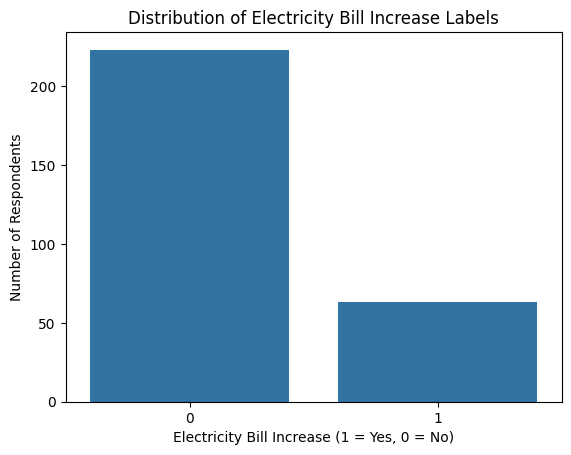

In [ ]:
sns.countplot(x='label_kenaikan', data=df)
plt.title("Distribution of Electricity Bill Increase Labels")
plt.xlabel("Electricity Bill Increase (1 = Yes, 0 = No)")
plt.ylabel("Number of Respondents")
plt.show()


## MERGE FEATURE & TARGET

In [ ]:
mapped_cols = [col for col in df.columns if col.endswith('_mapped')]

numeric_original_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

exclude_cols = (
    mapped_cols +
    ['label_kenaikan'] +
    [c for c in df.columns if c.endswith('_clean')]
)

numeric_original_cols = [
    col for col in numeric_original_cols
    if col not in exclude_cols
]

final_feature_cols = mapped_cols + numeric_original_cols

print("Jumlah fitur akhir:", len(final_feature_cols))



Jumlah fitur akhir: 47


In [ ]:
df_clean = df.dropna(subset=['label_kenaikan'])

X = df_clean[final_feature_cols]
y = df_clean['label_kenaikan']

## SCALED DATASET (UNUSED)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

df_final = X_scaled.copy()
df_final['label_kenaikan'] = y.values


## SMOTE

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = df_clean[final_feature_cols]
y = df_clean['label_kenaikan']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


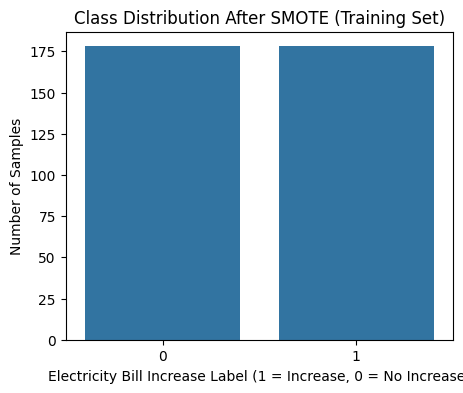

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x=y_train_res)
plt.title("Class Distribution After SMOTE (Training Set)")
plt.xlabel("Electricity Bill Increase Label (1 = Increase, 0 = No Increase)")
plt.ylabel("Number of Samples")
plt.show()


## KNN FINAL

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

for k in [3,5,7,9,11]:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        weights='distance',
        metric='euclidean'
    )

    knn.fit(X_train_res, y_train_res)
    y_pred = knn.predict(X_test)

    print(f"\nK = {k}")
    print(classification_report(y_test, y_pred))



K = 3
              precision    recall  f1-score   support

           0       0.75      0.53      0.62        45
           1       0.19      0.38      0.26        13

    accuracy                           0.50        58
   macro avg       0.47      0.46      0.44        58
weighted avg       0.62      0.50      0.54        58


K = 5
              precision    recall  f1-score   support

           0       0.76      0.58      0.66        45
           1       0.21      0.38      0.27        13

    accuracy                           0.53        58
   macro avg       0.49      0.48      0.46        58
weighted avg       0.64      0.53      0.57        58


K = 7
              precision    recall  f1-score   support

           0       0.76      0.58      0.66        45
           1       0.21      0.38      0.27        13

    accuracy                           0.53        58
   macro avg       0.49      0.48      0.46        58
weighted avg       0.64      0.53      0.57        58

## MLP FINAL

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

# Urutan dibuat bertahap & enak dibaca
configs = [
    # Single hidden layer
    (16,),
    (32,),

    # Two hidden layers
    (32, 8),
    (32, 16),
    (32, 32),
    (64, 32),

    # Three hidden layers
    (64, 32, 16)
]

for cfg in configs:
    mlp = MLPClassifier(
        hidden_layer_sizes=cfg,
        activation='relu',
        solver='adam',
        alpha=0.0005,
        learning_rate_init=0.001,
        max_iter=800,
        random_state=42
    )

    mlp.fit(X_train_res, y_train_res)
    y_pred = mlp.predict(X_test)

    print("="*60)
    print(f"Hidden Layers Configuration: {cfg}")
    print(classification_report(y_test, y_pred))


Hidden Layers Configuration: (16,)
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        45
           1       0.22      1.00      0.37        13

    accuracy                           0.22        58
   macro avg       0.11      0.50      0.18        58
weighted avg       0.05      0.22      0.08        58

Hidden Layers Configuration: (32,)
              precision    recall  f1-score   support

           0       0.78      1.00      0.87        45
           1       0.00      0.00      0.00        13

    accuracy                           0.78        58
   macro avg       0.39      0.50      0.44        58
weighted avg       0.60      0.78      0.68        58

Hidden Layers Configuration: (32, 8)
              precision    recall  f1-score   support

           0       0.78      1.00      0.87        45
           1       0.00      0.00      0.00        13

    accuracy                           0.78        58
   macro avg       0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Hidden Layers Configuration: (64, 32, 16)
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        45
           1       0.22      1.00      0.37        13

    accuracy                           0.22        58
   macro avg       0.11      0.50      0.18        58
weighted avg       0.05      0.22      0.08        58



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
